In [345]:
import numpy as np              # Одномерные и многомерные массивы (array)
import pandas as pd             # Таблицы и временные ряды (dataframe, series)
import matplotlib.pyplot as plt # Научная графика
import seaborn as sns           # Еще больше красивой графики для визуализации данных
import sklearn                  # Алгоритмы машинного обучения

# 0. Описание задачи
 Предсказать цену кофе, исходя из его названия и месяца в который был приобретен продукт. Найти решение, которое даст отличную точность угадывания(>90%) без использования таких "захардкоженных" решений, как " поиск значения по справочнику". Данная задача является задачей регрессии.


# 1. Загрузка данных
Данные данного датасета взяты с сайта
https://www.kaggle.com. Название датасета: "Coffee_Sales _Dataset".

In [346]:
url = "https://raw.githubusercontent.com/Korobokkk/Machine_learning/master/Coffe_sales.csv"
data_raw = pd.read_csv(url)

Посмотрим размеры таблицы.

In [347]:
data_raw.shape

(3547, 11)

In [348]:
data_raw

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.70,Latte,Morning,Fri,Mar,5,3,3/1/2024,15:50.5
1,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,3/1/2024,19:22.5
2,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,3/1/2024,20:18.1
3,13,card,28.90,Americano,Afternoon,Fri,Mar,5,3,3/1/2024,46:33.0
4,13,card,38.70,Latte,Afternoon,Fri,Mar,5,3,3/1/2024,48:14.6
...,...,...,...,...,...,...,...,...,...,...,...
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,3/23/2025,34:54.9
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,3/23/2025,43:37.4
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,3/23/2025,44:16.9
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,3/23/2025,47:28.7


In [349]:
data_raw.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


В текущем датасет отсутствуют пропущенные значения.
Посмотрим на переменные с которыми планируется работать для обучения
-   `coffee_name` - название кофе.('Americano', 'Americano with Milk', 'Cappuccino', 'Cocoa','Cortado', 'Espresso', 'Hot Chocolate', 'Latte') Планируется предсказывать данную категорию.
-   `Time_of_Day` - время суток ('Afternoon', 'Morning', 'Night')
-  `Weekday` -день недели ('Fri', 'Mon', 'Sat', 'Sun', 'Thu', 'Tue', 'Wed').
- `Month_name` -месяц в который прибрели продукт ('Apr', 'Aug', 'Dec', 'Feb', 'Jan', 'Jul', 'Jun', 'Mar',
                  'May', 'Nov', 'Oct', 'Sep').
- `money`- стоимость оплаченного продукта.  

In [350]:
data_raw['Time_of_Day'] = data_raw['Time_of_Day'].astype('category')
data_raw['Month_name'] = data_raw['Month_name'].astype('category')
data_raw['Weekday'] = data_raw['Weekday'].astype('category')
data_raw['coffee_name'] = data_raw['coffee_name'].astype('category')
data_raw['cash_type'] =data_raw['cash_type'].astype('category')

In [351]:
data_raw['Month_name'].dtype

CategoricalDtype(categories=['Apr', 'Aug', 'Dec', 'Feb', 'Jan', 'Jul', 'Jun', 'Mar',
                  'May', 'Nov', 'Oct', 'Sep'],
, ordered=False, categories_dtype=object)

In [352]:
data_raw['Time_of_Day'].dtype

CategoricalDtype(categories=['Afternoon', 'Morning', 'Night'], ordered=False, categories_dtype=object)

In [353]:
data_raw['Weekday'].dtype

CategoricalDtype(categories=['Fri', 'Mon', 'Sat', 'Sun', 'Thu', 'Tue', 'Wed'], ordered=False, categories_dtype=object)

In [354]:
data_raw['coffee_name'].dtype

CategoricalDtype(categories=['Americano', 'Americano with Milk', 'Cappuccino', 'Cocoa',
                  'Cortado', 'Espresso', 'Hot Chocolate', 'Latte'],
, ordered=False, categories_dtype=object)

Проверка на многообразность `cash_type`

In [355]:
data_raw['cash_type'].dtype

CategoricalDtype(categories=['card'], ordered=False, categories_dtype=object)

`cash_type` не имеет разнообразия, дропаем его из .csv

In [356]:
data_raw.drop('cash_type', axis=1, inplace=True)

Проверка

In [357]:
data_raw.shape

(3547, 10)

Информация о категориальных признаках

In [358]:
data_raw.describe(include=['category'])

,coffee_name,Time_of_Day,Weekday,Month_name
count,3547,3547,3547,3547
unique,8,3,7,12
top,Americano with Milk,Afternoon,Tue,Mar
freq,809,1205,572,494


## Проверка на пустые значения

In [359]:
data_raw.isnull().sum()

,0
hour_of_day,0
money,0
coffee_name,0
Time_of_Day,0
Weekday,0
Month_name,0
Weekdaysort,0
Monthsort,0
Date,0
Time,0


Убедились, что пропущенных значений нет.

# 2. Разбиваем данные
Разбиваем данные на обучающую и тестовую выборку.
Чтобы не переобучить модель, планируется на время анализа исключить следующие поля: `Date`, `Time`, `hour_of_day`, `Weekday`,`Weekdaysort`, `Time_of_Day`.

In [360]:
X = data_raw[['coffee_name', 'Month_name']]
y = data_raw['money']

Разбиваем данные на обучающую и тестирующую выборки в пропорциях 3:1

In [361]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

N_train, _ = X_train.shape
N_test,  _ = X_test.shape

N_train, N_test

print (y_train.describe())

print (y_test.describe())

count    2660.000000
mean       31.585053
std         4.886676
min        18.120000
25%        27.920000
50%        32.820000
75%        35.760000
max        38.700000
Name: money, dtype: float64
count    887.000000
mean      31.825637
std        4.849167
min       18.120000
25%       27.920000
50%       32.820000
75%       35.760000
max       38.700000
Name: money, dtype: float64


# 3 Виртуализация данных
Проверим, есть ли изменение цены кофе в зависимости от месяца

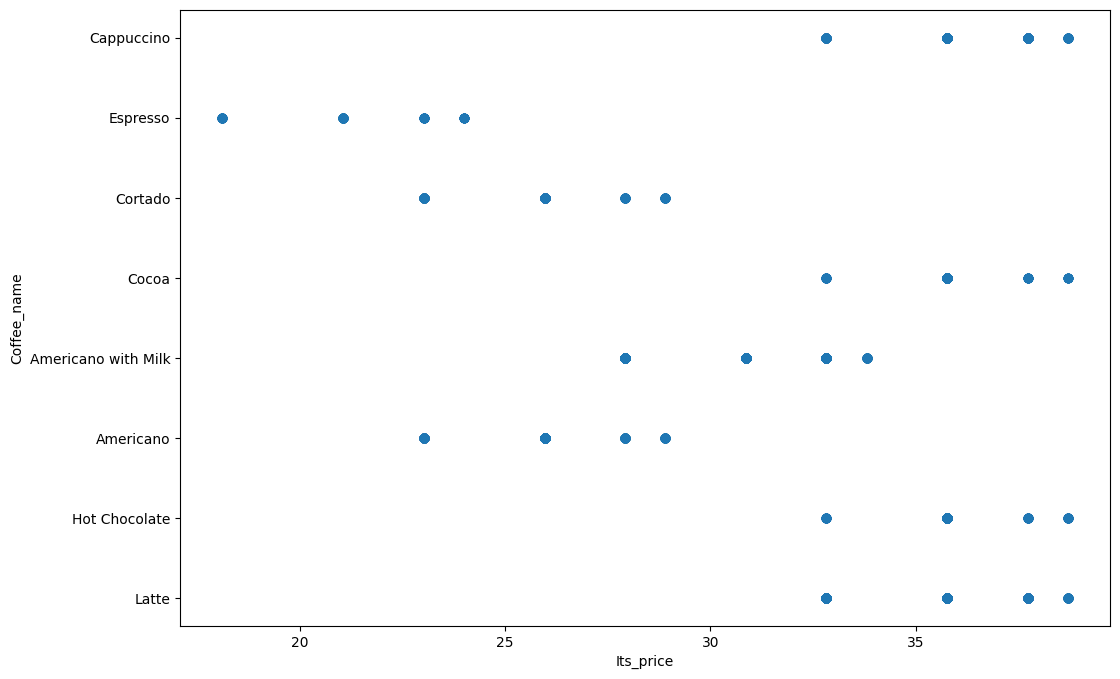

In [362]:
plt.figure(figsize=(12, 8)) #меняю стандартный размер графика
plt.scatter(data_raw['money'], data_raw['coffee_name'])
plt.xlabel('Its_price')
plt.ylabel('Coffee_name')
pass

Очевидно, цена кофе меняется в зависимости от месяца

Зависимость средней цены от месяца

/tmp/ipython-input-2283524756.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = data_raw.groupby('Month_name')['money'].mean().sort_values()


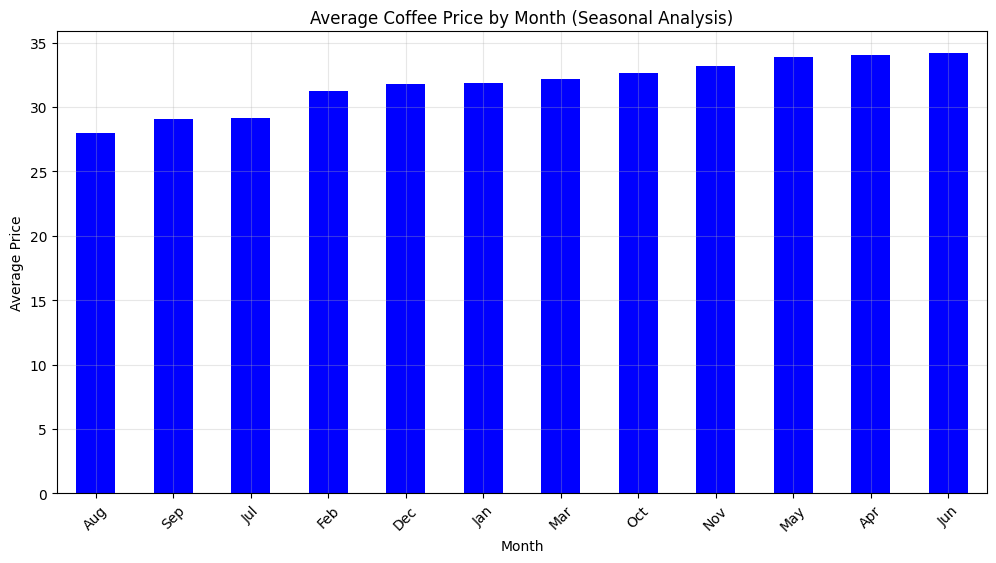

In [363]:
plt.figure(figsize=(12, 6))
monthly_avg = data_raw.groupby('Month_name')['money'].mean().sort_values()
monthly_avg.plot(kind='bar', color='blue')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.title('Average Coffee Price by Month (Seasonal Analysis)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()


Очевидно средний чек за напиток зависит от месяца.

Оценим, как часто покупают каждый вид кофе в зависимости от месяца.

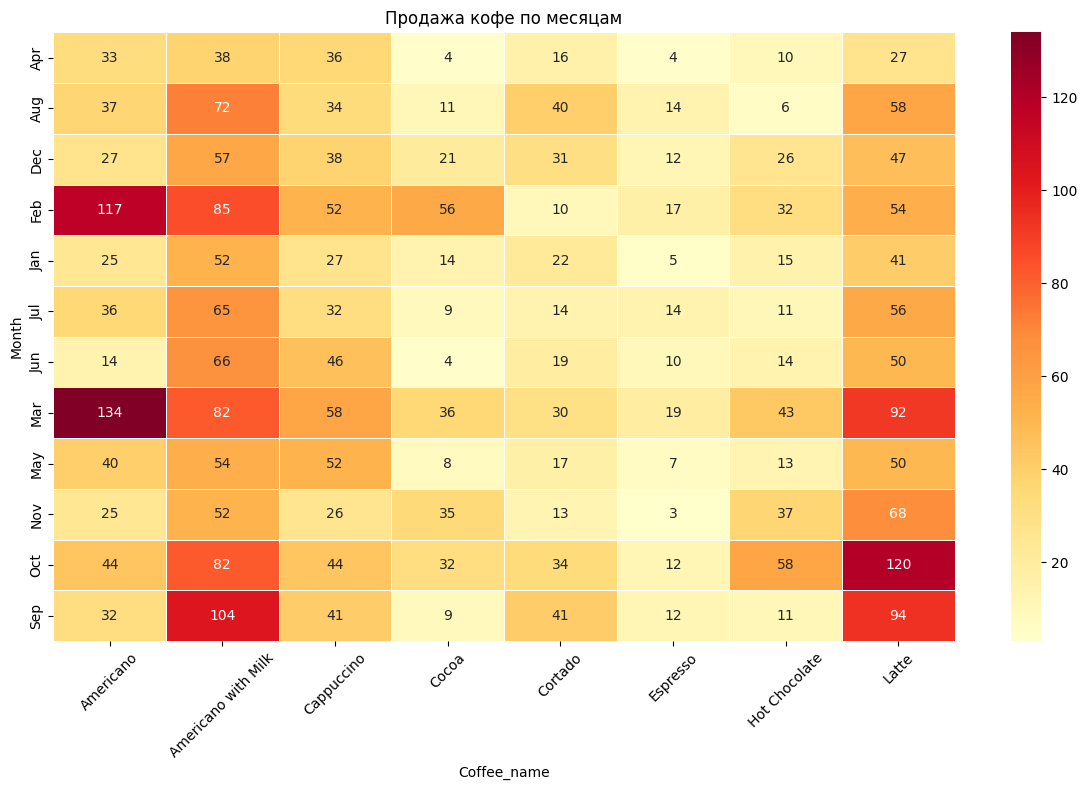

In [364]:
plt.figure(figsize=(12, 8))
monthly_coffee = data_raw.groupby(['Month_name', 'coffee_name'], observed=False).size().unstack(fill_value=0)

sns.heatmap(monthly_coffee,
           annot=True,
           fmt='d',
           cmap='YlOrRd',
           linewidths=0.5)
plt.title('Продажа кофе по месяцам')
plt.xlabel('Coffee_name')
plt.ylabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Особенно выделяются `Americano`, `Americano and milk`, `Cappuccino`, `Latte`

Теперь построим топ 5 по продажам кофе за месяц.

<Figure size 1200x800 with 0 Axes>

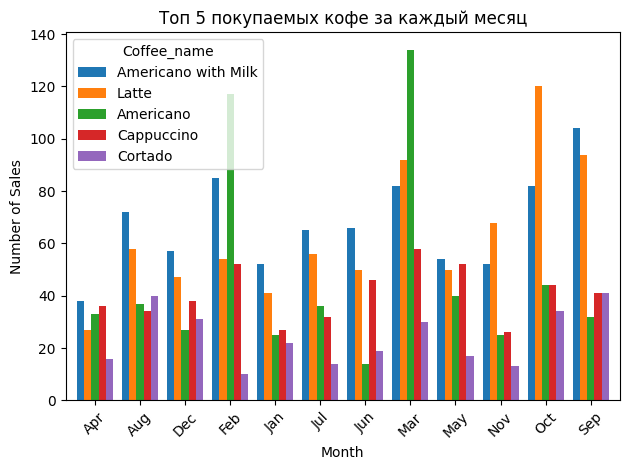

In [365]:
monthly_coffee = data_raw.groupby(['Month_name', 'coffee_name'], observed=False).size().unstack(fill_value=0)
top_coffees = data_raw['coffee_name'].value_counts().head(5).index
monthly_top = monthly_coffee[top_coffees]

#ГРАФИК
plt.figure(figsize=(12, 8))
monthly_top.plot(kind='bar', width=0.8)# width для лучшего отображения
plt.title('Топ 5 покупаемых кофе за каждый месяц')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.legend(title='Coffee_name')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

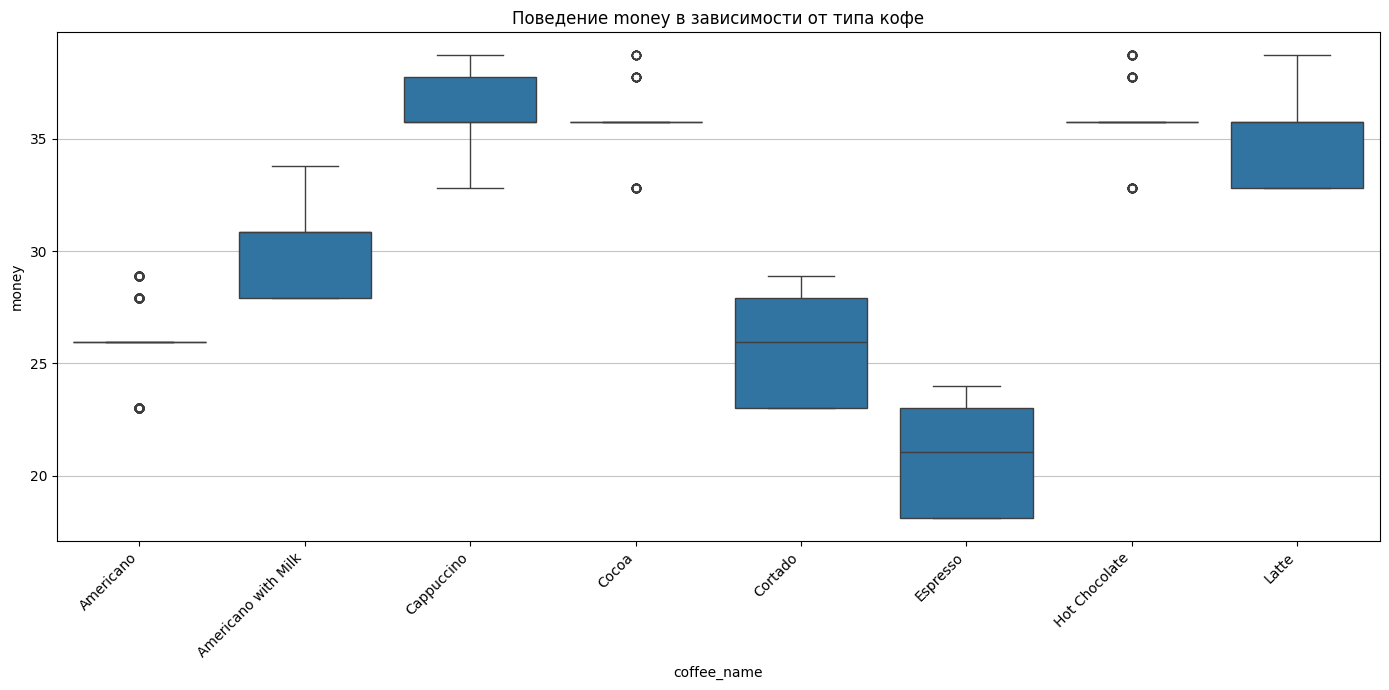

In [366]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='coffee_name', y='money', data=data_raw)
plt.xlabel('сoffee_name')
plt.ylabel('money')
plt.title('Поведение money в зависимости от типа кофе')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

При одинаковой стоимости продуктов, можно делать упор на  данные из графика и отдавать предпочтение наиболее приобретаемым продуктам.

Строим корреляционную матрицу

Корреляционная матрица
             hour_of_day     money  Weekdaysort  Monthsort
hour_of_day     1.000000  0.202748    -0.002614   0.008293
money           0.202748  1.000000    -0.017264  -0.050043
Weekdaysort    -0.002614 -0.017264     1.000000   0.044141
Monthsort       0.008293 -0.050043     0.044141   1.000000


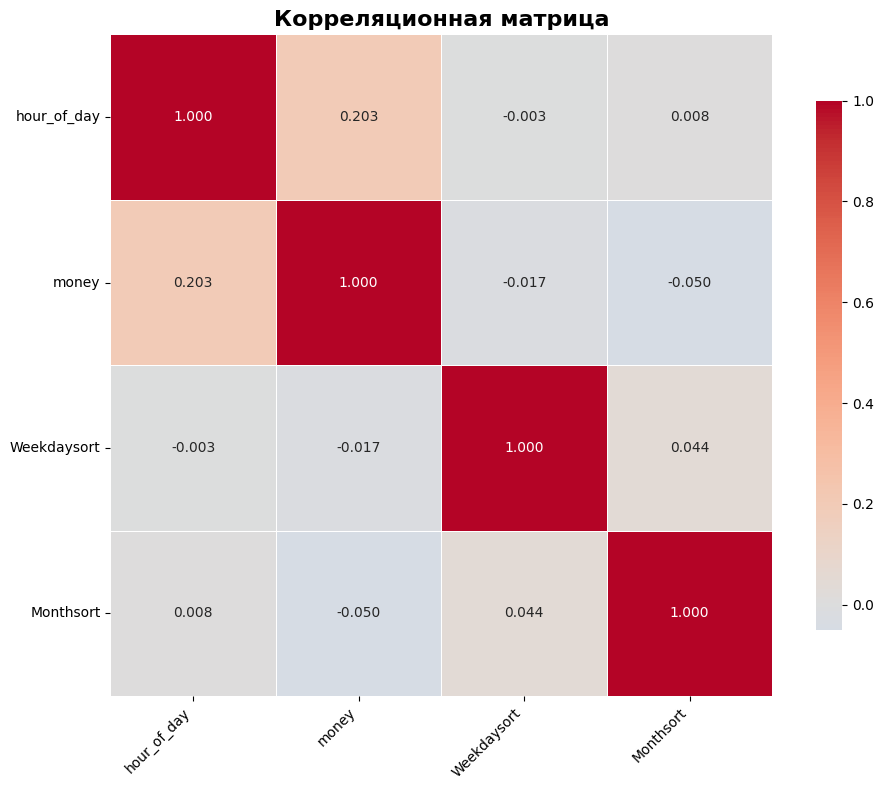

In [367]:
numeric_columns = ['hour_of_day', 'money', 'Weekdaysort', 'Monthsort']#строим ток по числовым значениям
numeric_data = data_raw[numeric_columns]

correlation_matrix = numeric_data.corr()
print("Корреляционная матрица")
print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
           annot=True,
           cmap='coolwarm',
           center=0,
           square=True,
           fmt='.3f',
           linewidths=0.5,
           cbar_kws={'shrink': 0.8})

plt.title('Корреляционная матрица', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Корреляционная матрица видит некоторую связь между `money` и `hour_of_day`, и не видит линейной зависимости между `money` и `mintsort`, хотя очевидно, что связь между данными есть(что подтверждается графиком со средним чеком за месяц). Корреляционный подход не учитывает сезонность и другие факторы.  
При необходимости повышения точности прогнозов, нужно рассмотреть возможность учета данных из категории `hour_of_day` для определения `money`.

# 4 Пропущенные значения
Пропущенных значений нет

In [368]:
data_raw.isnull().sum()

,0
hour_of_day,0
money,0
coffee_name,0
Time_of_Day,0
Weekday,0
Month_name,0
Weekdaysort,0
Monthsort,0
Date,0
Time,0


# 5. Обработать категориальные признаки
Для интерпритации наших категориальных признаков в читаемый вид для машины.
Ранее я уже делал перевод объектов object -> category.
Убедимся

In [369]:
print("ТИПЫ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:")
print(f"coffee_name: {data_raw['coffee_name'].dtype}")
print(f"Time_of_Day: {data_raw['Time_of_Day'].dtype}")
print(f"Weekday: {data_raw['Weekday'].dtype}")
print(f"Month_name: {data_raw['Month_name'].dtype}")

ТИПЫ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:
coffee_name: category
Time_of_Day: category
Weekday: category
Month_name: category


Посмотрим статистику данных признаков.

In [370]:
print("СТАТИСТИКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
categorical_stats = data_raw.describe(include=['category'])
print(categorical_stats)

СТАТИСТИКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
                coffee_name Time_of_Day Weekday Month_name
count                  3547        3547    3547       3547
unique                    8           3       7         12
top     Americano with Milk   Afternoon     Tue        Mar
freq                    809        1205     572        494


Для того чтобы машина смогла понять признаки, преобразуем их в числовые значения

In [371]:
print("ПРЕОБРАЗОВАНИЕ В ЧИСЛОВЫЕ ЗНАЧЕНИЯ")

# Для coffee_name - создаем мэппинг по средней цене каждого кофе
coffee_price_mapping = data_raw.groupby('coffee_name')['money'].mean().to_dict()
#средняя цена может пригодиться
print("средняя цена для coffee_name:")
for coffee, price in coffee_price_mapping.items():
    print(f"  {coffee}: {price:.2f}")

coffee_mapping = {coffee: i for i, coffee in enumerate(data_raw['coffee_name'].value_counts().index)}#удобный способ
time_mapping = {'Morning': 1, 'Afternoon': 2, 'Night': 3}#мейби нужно переделать на удобный
weekday_mapping = {'Mon': 1, 'Tue': 2, 'Wed': 3, 'Thu': 4, 'Fri': 5, 'Sat': 6, 'Sun': 7}
month_mapping = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}

print(f"\nМаппинг для coffee_name: {coffee_mapping}")
print(f"Мэппинг для Time_of_Day: {time_mapping}")
print(f"Мэппинг для Weekday: {weekday_mapping}")
print(f"Мэппинг для Month_name: {month_mapping}")

ПРЕОБРАЗОВАНИЕ В ЧИСЛОВЫЕ ЗНАЧЕНИЯ
средняя цена для coffee_name:
  Americano: 25.98
  Americano with Milk: 30.59
  Cappuccino: 35.88
  Cocoa: 35.65
  Cortado: 25.73
  Espresso: 20.85
  Hot Chocolate: 35.99
  Latte: 35.50

Маппинг для coffee_name: {'Americano with Milk': 0, 'Latte': 1, 'Americano': 2, 'Cappuccino': 3, 'Cortado': 4, 'Hot Chocolate': 5, 'Cocoa': 6, 'Espresso': 7}
Мэппинг для Time_of_Day: {'Morning': 1, 'Afternoon': 2, 'Night': 3}
Мэппинг для Weekday: {'Mon': 1, 'Tue': 2, 'Wed': 3, 'Thu': 4, 'Fri': 5, 'Sat': 6, 'Sun': 7}
Мэппинг для Month_name: {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}


/tmp/ipython-input-1094224966.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  coffee_price_mapping = data_raw.groupby('coffee_name')['money'].mean().to_dict()


Теперь применяем маппинг к данным

In [372]:
data_raw['coffee_name_encoded'] = data_raw['coffee_name'].map(coffee_mapping)
data_raw['Time_of_Day_encoded'] = data_raw['Time_of_Day'].map(time_mapping)
data_raw['Weekday_encoded'] = data_raw['Weekday'].map(weekday_mapping)
data_raw['Month_name_encoded'] = data_raw['Month_name'].map(month_mapping)

#Проверка
print("\nПервые 5 строк после преобразования:")
print(data_raw[['coffee_name', 'coffee_name_encoded',
                'Time_of_Day', 'Time_of_Day_encoded',
                'Weekday', 'Weekday_encoded',
                'Month_name', 'Month_name_encoded']].head())


Первые 5 строк после преобразования:
     coffee_name coffee_name_encoded Time_of_Day Time_of_Day_encoded Weekday  \
0          Latte                   1     Morning                   1     Fri   
1  Hot Chocolate                   5   Afternoon                   2     Fri   
2  Hot Chocolate                   5   Afternoon                   2     Fri   
3      Americano                   2   Afternoon                   2     Fri   
4          Latte                   1   Afternoon                   2     Fri   

  Weekday_encoded Month_name Month_name_encoded  
0               5        Mar                  3  
1               5        Mar                  3  
2               5        Mar                  3  
3               5        Mar                  3  
4               5        Mar                  3  


# 6 Нормализация


После перевода категориальных значений в числовые нужно сделать переразбивку данных, предыдущее разбиение не учитывает перевод.
Выбираем признаки для модели и разбиваем.

**Важное уточнение**: нормализация не нужна для `RandomForest`, но пригодится для `KNeighbors` и `LinerarRegression`.

In [373]:
print (y_train.describe()) #для сравнения числа элементов(вдруг потеряли данные)

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

X_train_encoded['coffee_name_encoded'] = data_raw.loc[X_train_encoded.index, 'coffee_name_encoded']
X_train_encoded['Month_name_encoded'] = data_raw.loc[X_train_encoded.index, 'Month_name_encoded']

X_test_encoded['coffee_name_encoded'] = data_raw.loc[X_test_encoded.index, 'coffee_name_encoded']
X_test_encoded['Month_name_encoded'] = data_raw.loc[X_test_encoded.index, 'Month_name_encoded']

X_train_encoded = X_train_encoded[['coffee_name_encoded', 'Month_name_encoded']]
X_test_encoded = X_test_encoded[['coffee_name_encoded', 'Month_name_encoded']]

numeric_cols = ['coffee_name_encoded', 'Month_name_encoded']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train_encoded[numeric_cols])

X_train_encoded = pd.DataFrame(scaler.transform(X_train_encoded[numeric_cols]),
                              columns=numeric_cols,
                              index=X_train_encoded.index)

X_test_encoded = pd.DataFrame(scaler.transform(X_test_encoded[numeric_cols]),
                             columns=numeric_cols,
                             index=X_test_encoded.index)

print("\n=== ТРЕНИРОВОЧНЫЕ ДАННЫЕ ПОСЛЕ НОРМАЛИЗАЦИИ ===")
print(X_train_encoded.describe())

count    2660.000000
mean       31.585053
std         4.886676
min        18.120000
25%        27.920000
50%        32.820000
75%        35.760000
max        38.700000
Name: money, dtype: float64

=== ТРЕНИРОВОЧНЫЕ ДАННЫЕ ПОСЛЕ НОРМАЛИЗАЦИИ ===
       coffee_name_encoded  Month_name_encoded
count         2.660000e+03        2.660000e+03
mean          4.941745e-17        1.041773e-16
std           1.000188e+00        1.000188e+00
min          -1.135888e+00       -1.562224e+00
25%          -6.487128e-01       -9.922724e-01
50%          -1.615372e-01        1.476302e-01
75%           8.128140e-01        1.002557e+00
max           2.274341e+00        1.572509e+00


Сразу заметим:

`count`:  
- объемы данных совпадают.
- обработка прошла успешно и пропущенные значения отсутствуют\не появились
- количество данных довольно большое, это

`mean` ~ 0
- значит нормальзация правильная и данные отцентрованы

`std` ~ 1
 - идеальный разброс для переменных


### Рассмотрим `coffee_name_encoded`

Разброс: [-1.14 , 2.27]

Медиана: ~ (-0.16)

Более высокая плотность у кофе из первой половины списка.
### Теперь `Month_name_encoded`
Разброс: [-1.56 , 1.57]

Медиана: ~ (0.15)

Более высокая плотность потребления в месяцы из второй половины списка. Очевидно присутствует сезонность.

# 7 Запуск модели


# 7.1 LinearRegression

В данном запуске будет использоваться модель `LinearRegression` (линейная регрессия).

***ВНИМАНИЕ*** : выбор переменных изначально был приспособлен для модели  `RandomForestRegressor`. Линейная регрессионная модель **не может дать адекватных результатов**, хотя бы потому, что имеет очень мало признаков.

In [374]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_encoded, y_train)

y_train_predict = model.predict(X_train_encoded)

from sklearn.metrics import r2_score
print(f"Точность предсказания на тестовой выборке: {r2_score(y_train, y_train_predict):.4f}")

Точность предсказания на тестовой выборке: 0.0053


Текущая модель дала **ужасный** результат с точностью прогноза ~0.5%. На этапе прогнозирования из матрицы корреляции стало очевидно, что линейные зависимости практически не улавливаются. Даже при использовании всевозможных коэффициентов точность будет недостаточной (очевидно менее 90%, предположительно 10-40% 🙃).

# 7.2 RandomForestRegressor

Данный блок должен быть расположен на 9 этапе, однако, поскольку для `LinearRegression` быстрее и проще указать совпадения нежели ошибки, выполним этот этап сейчас.

Модель `RandomForestRegressor` по сути представляет из себя комбинацию множества слабых моделей, которые в совокупности дают сильную модель.

Создается 200 деревьев и для каждого берет некоторую случайную подвыборку данных, выбираются случайные признаки и строится некоторое дерево, исходя из которого будет пресказываться цена кофе

In [375]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
#mean_absolute_error с рандомный момент просто перестал подгружаться

rf_model = RandomForestRegressor(n_estimators=200)
rf_model.fit(X_train_encoded, y_train)


print(f"Точность предсказания на обучающей выборке:(R^2) = {R2_train:.4f}")
print(f"Точность предсказания на тестовой выборке:(R^2) = {R2_test:.4f}")


Точность предсказания на обучающей выборке:(R^2) = 0.9798
Точность предсказания на тестовой выборке:(R^2) = 0.9764


Данный метод дал точность в ~97.64% на тестовой выборке и 97.98% на обучающей, что является **отличным** результатом.
Он имеет ряд недостатков, таких как избыточность для простых задч или большее количество ресурсов для обучения, однако при необходимости более точных прогнозов подходит лучше.
Свою роль сыграли и правильно выбранные коэффициенты, которые практически достоверно описывют искомый элемент.

 Маленький процент ошибок может появляться по нескольким причинам

*   генерируемые деревья описывают не все возможные случаи, встречающиеся в тестовой выборке
*   возможен случай, когда цена на позицию поменялась не в конце месяца, а например в середине

В любом случае ошибка предсказания очень мала и попытка её исправить добавлением других переменных практически гарантированно приведет к снижению точности модели(поскольку деревья могут строиться на безе не всех используемых признаков, и потеря названия кофе или месяца будет роковой).



Очевидно является лучшим выбором в сравнение с линейной регрессии.
Однако, нельзя однозначно утверждать, что он наилучший, среди всех методов. На ум приходит ещё 2 способа, которые могут дать сопоставимый, а может быть даже лучший результат, например:
1.   Таблица с "прозрачными" правилами
2.   метод k-ближвйших соседей

Если первый подход по сути является хардкодингом и даст достоверный ответ,
то метод k ближайших соседей- должен подойти.



# 7.3 KNeighborsRegressor

Метод `KNeighborsRegressor` смотрит на k ближайших соседей и по ним предсказывает значение элемента.
Данные метод легко адаптируется к новым данным, и является одним из простых базовых методов. Из недостатков: медленнный и не подходит для больших данных,а также очень чувствительный к выбросам.

In [376]:
from sklearn.neighbors import KNeighborsRegressor

# Если одинаковые кофе+месяц всегда имеют одинаковую цену
knn_model = KNeighborsRegressor(n_neighbors=1)  #n_neighbors=10 дает наилучший результат для текущей выборки,  при выборе n_neighbors=1 точность  9.666...
knn_model.fit(X_train_encoded, y_train)

y_pred_knn = knn_model.predict(X_test_encoded)
r2_knn = r2_score(y_test, y_pred_knn)
print(f"KNN (k=1) R²: {r2_knn:.4f}")

KNN (k=1) R²: 0.9666


In [377]:
from sklearn.neighbors import KNeighborsRegressor

# Если одинаковые кофе+месяц всегда имеют одинаковую цену
knn_model = KNeighborsRegressor(n_neighbors=10)  #n_neighbors=10 дает наилучший результат для текущей выборки,  при выборе n_neighbors=1 точность  9.666...
knn_model.fit(X_train_encoded, y_train)

y_pred_knn = knn_model.predict(X_test_encoded)
r2_knn = r2_score(y_test, y_pred_knn)
print(f"KNN (k=10) R²: {r2_knn:.4f}")

KNN (k=10) R²: 0.9752


Точность:
- при K=1 на тестовой выборке 96.66%,
- при K=10 на тестовой выборке 97.50%

более эффективный коэффициен подобрал перебором.


Данный алгоритм дал результаты незначительно отличающиеся в меньшую сторону от метода случайных деревьев.

# 8 ошибки на обучающей и тестовой выборках

Посмотрим на 20 встретившихся ошибок.

In [378]:
errors_df = pd.DataFrame({
    'Строка_в_CSV': X_test_encoded.index,
    'Month_name': data_raw.loc[X_test_encoded.index, 'Month_name'],
    'coffee_name': data_raw.loc[X_test_encoded.index, 'coffee_name'],
    'csv_money': y_test.values,
    'Предсказанное_money': y_test_pred,
    'Величина ошибки': y_test_pred - y_test.values,
})
errors_filtered = errors_df[errors_df['Величина ошибки'] != 0]
first_n_errors = errors_filtered.head(20)

print(first_n_errors.to_string(index=False))


 Строка_в_CSV Month_name         coffee_name  csv_money  Предсказанное_money  Величина ошибки
          299        Apr Americano with Milk      32.82            33.251491     4.314913e-01
         2550        Dec               Latte      35.76            35.760000     1.705303e-13
         3079        Feb          Cappuccino      35.76            35.760000     1.563194e-13
         2342        Nov               Cocoa      35.76            35.760000     1.634248e-13
         1211        Aug            Espresso      18.12            18.120000    -7.815970e-14
         1729        Oct               Latte      35.76            35.760000     1.705303e-13
         1583        Sep           Americano      23.02            23.145678     1.256778e-01
         2131        Nov          Cappuccino      35.76            35.760000     1.563194e-13
         2113        Nov           Americano      25.96            25.960000     3.197442e-14
         3080        Feb Americano with Milk      30.86     

Маленький процент ошибок может появляться по нескольким причинам

*   генерируемые деревья описывают не все возможные случаи, встречающиеся в тестовой выборке
*   возможен случай, когда цена на позицию поменялась не в конце месяца, а например в середине

Ошибка очень мала и попытка её исправить добавлением других переменных практически гарантированно приведет к снижению точности модели(поскольку деревья могут строиться на безе не всех используемых признаков, и потеря названия кофе или месяца будет роковой).

Пустые значения отсутствуют, сразу приступаем к метрикам.

In [379]:
from sklearn.metrics import mean_squared_error, r2_score

y_train_predict = rf_model.predict(X_train_encoded)
y_test_predict = rf_model.predict(X_test_encoded)

MSE_train = mean_squared_error(y_train, y_train_predict)
MSE_test  = mean_squared_error(y_test,  y_test_predict)
R2_train = r2_score(y_train, y_train_predict)
R2_test  = r2_score(y_test,  y_test_predict)

print(f"MSE_train = {MSE_train}")
print(f"MSE_test = {MSE_test}")
print(f"R²_train = {R2_train}")
print(f"R²_test = {R2_test}")

print(f"Коэффициент детерминации для train = {model.score(X_train_encoded , y_train)}")
print(f"Коэффициент детерминации для test  = {model.score(X_test_encoded, y_test)}")

MSE_train = 0.4832229369691824
MSE_test = 0.5557591729405759
R²_train = 0.9797565863053331
R²_test = 0.9763384981852767
Коэффициент детерминации для train = 0.0052891711131983765
Коэффициент детерминации для test  = 0.005684973056199527


In [380]:
RMSE_table = pd.DataFrame(columns=('train', 'test'))
RMSE_table.loc['RandomForestRegressor', :] = (RMSE_train, RMSE_test)

RMSE_table

,train,test
RandomForestRegressor,0.695154,0.745451


In [381]:


R2_table = pd.DataFrame(columns=('train', 'test'))
R2_table.loc['RandomForestRegressor', :] = (R2_train, R2_test)
R2_table

,train,test
RandomForestRegressor,0.979757,0.976338


Доп параметры для Random Forest

In [382]:
importances = rf_model.feature_importances_
importances

array([0.88800891, 0.11199109])

In [383]:
np.sum(importances)

np.float64(1.0)

In [384]:
importances = pd.Series(rf_model.feature_importances_, index=X_train_encoded.columns).sort_values(ascending=False)
importances

,0
coffee_name_encoded,0.888009
Month_name_encoded,0.111991


Доля влияния полей

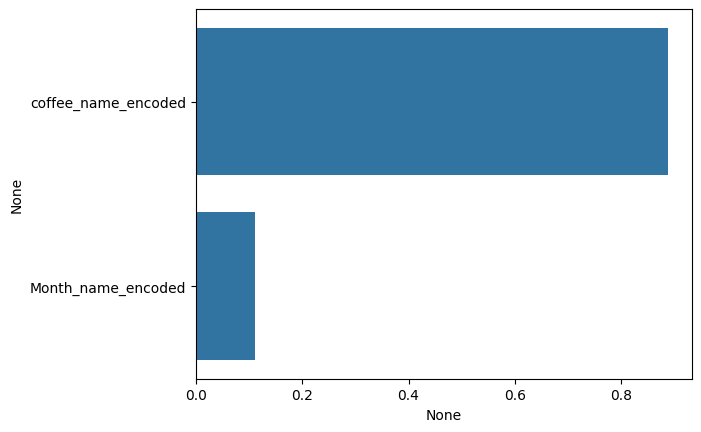

In [386]:
sns.barplot(y=importances.index, x=importances, orient="h")
pass

Подавляющий вклад(~90%) вносит название кофе

Для метода `KNeighbor` был определен оптимальный коэффициент k=10. который повышает точность предсказания на ~1%. он был найден серией экспериментов, сначала для k=1? потом k=2, k=4, k=16, k=(16+4)/2= k(10), k(11),k(9). и некоторых других коэфф-ов k, которые не дали лучшего результата точности эвристики.

# 9 Сравнение результатов

Среди сравняемых методов я подробно описал `RandomForestRegression`, поскольку он дал наиболее точный результат в сравнении с другими методами(97.64%).
Чуть меньший результат с разрывом в 1% дал `KNeighborsRegressor`. Тут важно заметить, что **правильно выбранный коэф. k** практически нивелирует преимущество случайного леса (97.64% Vs. 97.5) и разрыв уменьшается до 0.14% что довольно важно, если нужно получить максимально правдивый результат, но при первичном или поверхностном анализе не отличимо.

Также мною был рассмотрен метод `LinearRegression`. Ожидаемо он не дал никакого результата и оказался немного лучше слепого угадывания(0.5% Vs. ???). Тем не менее рассмотрение данного метода было очень информативным, поскольку необходимо понимать, как выбор неподходящего алгоритма может сказаться на результатах. К причинам такой низкой точности данного метода можно отнести малое количество рассматриваемых параметров и отсутствие(крайне низкой) видимой линейной связи между параметрами.

# 10 Общие выводы


Работая с текущим dataset, я смог найти решение, которое обеспечило точность предсказания в 97.64% что является отличным по точности результатом. Также были рассмотрены другие методы с меньшей точностью(подробнее в п. 7 и 9).

 Невозможно оставить без внимания, что огромный вклад в точность предсказания вносит выбор параметров для анализа, ограниченность в их числе, поскольку большое количество параметров может создать шум и(или) стать причиной переобучения модели.

Необходимо следить за наличием пустых значений и корректно их обрабатывать, иначе можно получить непредсказуемый результат.
Тоже самое с нормализацией.

 Каждый метод имеет свои плюсы и минусы и его грамотный выбор будет причиной "качественной" эвристики.

Данные полученные с помощью машинного обучения являются в большей степени аналитическим инструментом, который можно испоьзовать **В первую очередь** для отслеживания аномалий, например системой контроля, отлавливающей, ошибки в системе учета(обнаружение сильного расхождения прогнозируемого результата с реальной стоимостью).
А при небольших доработках можно использовать для:
- прогнозирования выручки на основе средней цены на каждую позицию за опредеоенный период при неизменных ценах (или измененных по ставке инфляции).
- анализа сезонности и ценовой стратегии. Полученные данные помогут определить как изменение цены в совокупности с сезонностью отразилось на спросе по каждой позиции.
- оптимизационных решений, таких как сокращение закупок одновременно наименее приобретаемых и дешевых видов кофе.
- сравнения данных с данными конкурентов и определение оптимальных стратегий продажи.

Но имеются и некоторые недочеты, модель не приспособленна для предсказания не выручки на будущее и требует переобучения, если появятся новы данные.